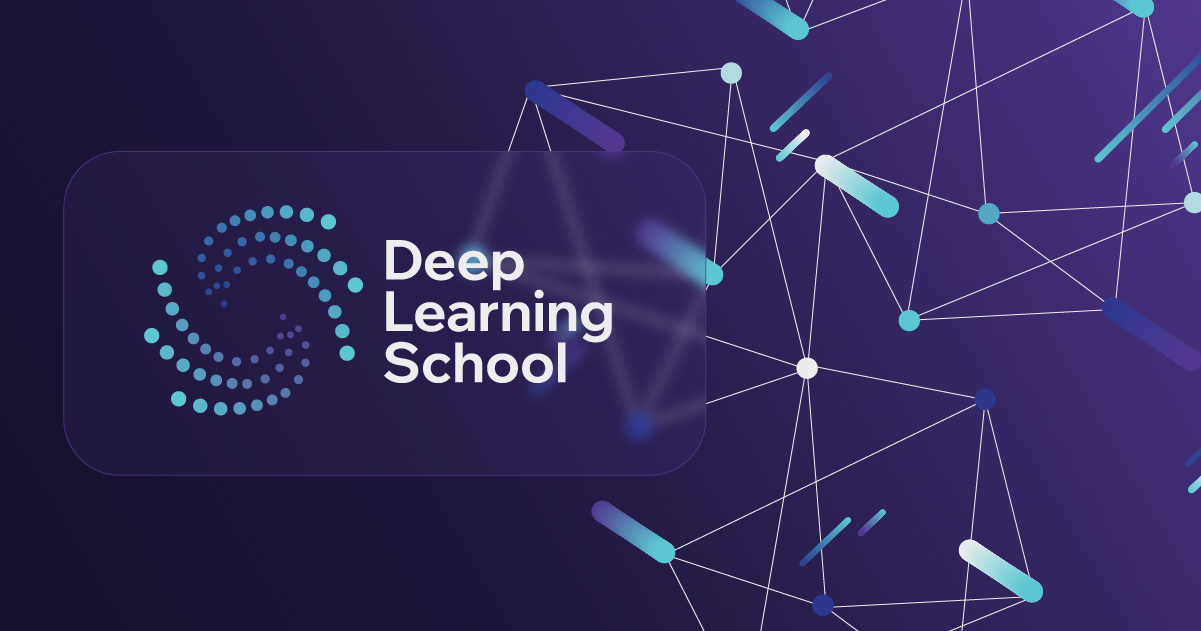

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Нейросетевая классификация текстов </b></h1>

В этом домашнем задании вам предстоит самостоятельно решить задачу классификации текстов на основе семинарского кода. Мы будем использовать датасет [ag_news](https://paperswithcode.com/dataset/ag-news). Это датасет для классификации новостей на 4 темы: "World", "Sports", "Business", "Sci/Tech".

Установим модуль datasets, чтобы нам проще было работать с данными.

In [1]:
# import os
# os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

In [2]:
# !pip install datasets

Импорт необходимых библиотек

In [3]:
import os
import random
import numpy as np
import torch
import sys

# Фиксирует все источники случайности
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

In [4]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import datasets

import matplotlib.pyplot as plt

from tqdm.auto import tqdm
# from datasets import load_dataset
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List
import string

import seaborn
seaborn.set_theme(palette='summer')

In [5]:
# nltk.download('punkt')

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных
Для вашего удобства, мы привели код обработки датасета в ноутбуке. Ваша задача --- обучить модель, которая получит максимальное возможное качество на тестовой части. 

In [7]:
# Загрузим датасет
dataset = datasets.load_dataset('ag_news')

Как и в семинаре, выполним следующие шаги:
* Составим словарь
* Создадим класс WordDataset
* Выделим обучающую и тестовую часть, создадим DataLoader-ы.

In [8]:
words = Counter()

for example in tqdm(dataset['train']['text']):
    # Приводим к нижнему регистру и убираем пунктуацию
    prccessed_text = example.lower().translate(
        str.maketrans('', '', string.punctuation))

    for word in word_tokenize(prccessed_text):
        words[word] += 1


vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
counter_threshold = 25

for char, cnt in words.items():
    if cnt > counter_threshold:
        vocab.add(char)

print(f'Размер словаря: {len(vocab)}')

word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

  0%|          | 0/120000 [00:00<?, ?it/s]

Размер словаря: 11842


In [9]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        processed_text = self.data[idx]['text'].lower().translate(
            str.maketrans('', '', string.punctuation))
        tokenized_sentence = [self.bos_id]
        tokenized_sentence += [
            word2ind.get(word, self.unk_id) for word in word_tokenize(processed_text)
            ] 
        tokenized_sentence += [self.eos_id]

        train_sample = {
            'text': tokenized_sentence,
            'label': self.data[idx]['label']
        }

        return train_sample

    def __len__(self) -> int:
        return len(self.data)


def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>'], max_len=256) -> torch.Tensor:
    seq_lens = [len(x['text']) for x in input_batch]
    max_seq_len = min(max(seq_lens), max_len)

    new_batch = []
    for sequence in input_batch:
        sequence['text'] = sequence['text'][:max_seq_len]
        for _ in range(max_seq_len - len(sequence['text'])):
            sequence['text'].append(pad_id)

        new_batch.append(sequence['text'])
    
    sequences = torch.LongTensor(new_batch).to(device)
    labels = torch.LongTensor([x['label'] for x in input_batch]).to(device)

    new_batch = {
        'input_ids': sequences,
        'label': labels
    }

    return new_batch

In [10]:
train_dataset = WordDataset(dataset['train'])

np.random.seed(42)
idx = np.random.choice(np.arange(len(dataset['test'])), 5000)
eval_dataset = WordDataset(dataset['test'].select(idx))

batch_size = 32
train_dataloader = DataLoader(
    train_dataset, shuffle=True, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, shuffle=False, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## Постановка задачи
Ваша задача -- получить максимальное возможное accuracy на `eval_dataloader`. Ниже приведена функция, которую вам необходимо запустить для обученной модели, чтобы вычислить качество её работы.

In [11]:
def evaluate(model, eval_dataloader) -> float:
    """
    Calculate accuracy on validation dataloader.
    """

    predictions = []
    target = []
    with torch.no_grad():
        for batch in eval_dataloader:
            logits = model(batch['input_ids'])
            predictions.append(logits.argmax(dim=1))
            target.append(batch['label'])
    
    predictions = torch.cat(predictions)
    target = torch.cat(target)
    accuracy = (predictions == target).float().mean().item()

    return accuracy

## Ход работы
Оценка за домашнее задание складывается из четырех частей:

### Запуск базовой модели с семинара на новом датасете (1 балл)

На семинаре мы создали модель, которая дает на нашей задаче довольно высокое качество. Ваша цель --- обучить ее и вычислить `score`, который затем можно будет использовать в качестве бейзлайна. 

В модели появится одно важное изменение: количество классов теперь равно не 2, а 4. Обратите на это внимание и найдите, что в коде создания модели нужно модифицировать, чтобы учесть это различие. 

Base model

In [12]:
class CharLM(nn.Module):
    def __init__(
        self, hidden_dim: int, 
        vocab_size: int, 
        num_classes: int = 4,   # 4 класса
        aggregation_type: str = 'max'
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.RNN(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

        self.aggregation_type = aggregation_type

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0] #[batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1) #[batch_size, hidden_dim]
        else:
            raise ValueError('Invalid aggregation_type')

        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, hidden_dim]
        prediction = self.projection(self.non_lin(output))  # [batch_size, num_classes]

        return prediction

In [13]:
model = CharLM(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters())

In [14]:
num_epoch = 5
eval_steps = len(train_dataloader) // 2

losses_type = {}
acc_type = {}

for aggregation_type in ['max', 'mean']:
    print(f'Starting training for {aggregation_type}')
    losses = []
    acc = []

    model = CharLM(hidden_dim=256, vocab_size=len(vocab), aggregation_type=aggregation_type).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    for epoch in range(num_epoch):
        epoch_losses = []
        model.train()
        for i, batch in enumerate(tqdm(train_dataloader, desc=f'Training epoch {epoch}:')):
            optimizer.zero_grad()
            logits = model(batch['input_ids'])
            loss = criterion(logits, batch['label'])
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            if i % eval_steps == 0:
                model.eval()
                acc.append(evaluate(model, eval_dataloader)) # + eval_dataloader
                model.train()

        losses.append(sum(epoch_losses) / len(epoch_losses))

    losses_type[aggregation_type] = losses
    acc_type[aggregation_type] = acc

Starting training for max


Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

...

Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/3750 [00:00<?, ?it/s]

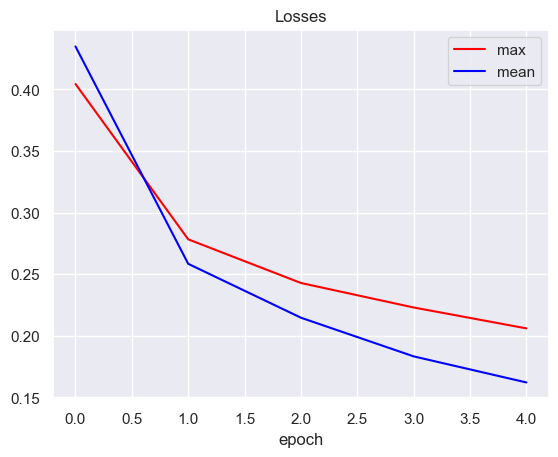

In [15]:
for (name, values), color in zip(losses_type.items(), ['red', 'blue']):
    plt.plot(np.arange(len(losses_type[name])), losses_type[name], color=color, label=name)

plt.title('Losses')
plt.xlabel('epoch')
plt.legend()

plt.show();

Лучшая accuracy для подхода max: 90.36
Лучшая accuracy для подхода mean: 90.70


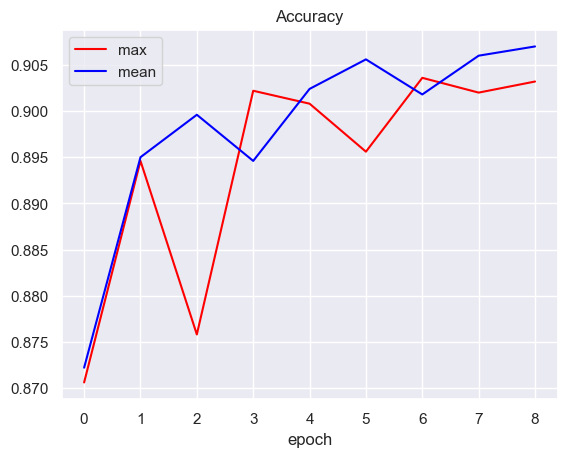

In [16]:
for (name, values), color in zip(losses_type.items(), ['red', 'blue']):
    plt.plot(np.arange(len(acc_type[name][1:])), acc_type[name][1:], color=color, label=name)
    print(f'Лучшая accuracy для подхода {name}: {(max(acc_type[name]) * 100):.2f}')

plt.title('Accuracy')
plt.xlabel('epoch')
plt.legend()

plt.show();

### Проведение экспериментов по улучшению модели (2 балла за каждый эксперимент)

Чтобы улучшить качество базовой модели, можно попробовать различные идеи экспериментов. Каждый выполненный эксперимент будет оцениваться в 2 балла. Для получения полного балла за этот пункт вам необходимо выполнить по крайней мере 2 эксперимента. Не расстраивайтесь, если какой-то эксперимент не дал вам прироста к качеству: он все равно зачтется, если выполнен корректно. 

Вот несколько идей экспериментов:
* **Модель RNN**. Попробуйте другие нейросетевые модели --- LSTM и GRU. Мы советуем обратить внимание на [GRU](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html), так как интерфейс этого класса ничем не отличается от обычной Vanilla RNN, которую мы использовали на семинаре.
* **Увеличение количества рекуррентных слоев модели**. Это можно сделать с помощью параметра `num_layers` в классе `nn.RNN`. В такой модели выходы первой RNN передаются в качестве входов второй RNN и так далее. 
* **Изменение архитектуры после применения RNN**. В базовой модели используется агрегация со всех эмбеддингов. Возможно, вы захотите конкатенировать результат агрегации и эмбеддинг с последнего токена.
* **Подбор гиперпараметров и обучение до сходимости**. Возможно, для получения более высокого качества просто необходимо увеличить количество эпох обучения нейросети, а также попробовать различные гиперпараметры: размер словаря, `dropout_rate`, `hidden_dim`.

Обратите внимание, что главное правило проведения экспериментов --- необходимо совершать одно архитектурное изменение в одном эксперименте. Если вы совершите несколько изменений, то будет неясно, какое именно из изменений дало прирост к качеству. 

Таблица для сравнения моделей

In [17]:
import pandas as pd 

# Значения Loss и Accuracy базовой модели RNN
base_max_loss = losses_type['max']
base_max_acc = acc_type['max']

base_mean_loss = losses_type['mean']
base_mean_acc = acc_type['mean']

# Сбор статистик для моделей
df_stats = pd.DataFrame(columns=['Model', 'Min_loss', 'Max_accuracy', 'Diff_accuracy'])

loss_base_max = min(base_max_loss)
acc_base_max = max(base_max_acc)

loss_base_mean = min(base_mean_loss)
acc_base_mean = max(base_mean_acc)

data_to_add = [
    ('base_mean', loss_base_mean, acc_base_mean, acc_base_mean - acc_base_mean),
    ('base_max', loss_base_max, acc_base_max, acc_base_max - acc_base_mean)
]

for i, (model, min_loss, max_accuracy, diff_accuracy) in enumerate(data_to_add):
    df_stats.loc[i] = [model, min_loss, max_accuracy, diff_accuracy]

display(df_stats)

,Model,Min_loss,Max_accuracy,Diff_accuracy
0,base_mean,0.162125,0.9070,0.0000
1,base_max,0.206021,0.9036,-0.0034


Для обучения и сравнения экспериментальной модели с базовой моделью RNN (mean подход) напишем функцию. <br>
При агрегации max в моделях сравниваем модели с base моделью с агрегацией max, <br>
в остальных случаях сравниваем с лучшей метрикой accuracy в base модели - mean.

In [18]:
from IPython.display import clear_output

# Функция для тренировки модели и сравнения текущей модели с базовой моделью RNN
def train_model(model, criterion, optimizer, 
                model_name='current',
                aggregation_type='mean',
                plot=True,
                num_epoch=5,
                base_mean_loss=base_mean_loss,
                base_mean_acc=base_mean_acc,
                train_loader=train_dataloader, 
                test_loader=eval_dataloader):

    eval_steps = len(train_loader) // 2

    total_loss = []
    total_acc = []

    print(f'\n{model_name} модель')

    for epoch in tqdm(range(num_epoch), desc=f'Training {model_name}'):
        epoch_train_loss = 0

        model.train()
        for i, batch in enumerate(train_loader):
            optimizer.zero_grad()
            logits = model(batch['input_ids'])
            loss = criterion(logits, batch['label'])
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()

            if i % eval_steps == 0:
                model.eval()
                total_acc.append(evaluate(model, test_loader))
                model.train()

        total_loss.append(epoch_train_loss / len(train_loader))

        if aggregation_type == 'max':
            base_loss = base_max_loss
            base_acc = base_max_acc
        else:
            base_loss = base_mean_loss
            base_acc = base_mean_acc   

        # Отрисовка графиков
        if plot:

            fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

            axes[0].plot(base_loss[:epoch+1], color='b', marker='o', markersize=4, label='base')
            axes[0].plot(total_loss, color='r', marker='o', markersize=4, label=model_name)

            axes[0].set_title('Losses')
            axes[0].set_xlabel('epoch')
            axes[0].set_ylabel('loss')
            axes[0].grid(True)
            axes[0].legend()


            axes[1].plot(base_acc[:(epoch+1)*2], color='b', marker='o', markersize=4, label='base')
            axes[1].plot(total_acc, color='r', marker='o', markersize=4, label=model_name)

            axes[1].set_title('Accuracy')
            axes[1].set_xlabel('epoch')
            axes[1].set_ylabel('accuracy')
            axes[1].set_ylim([0.87, 0.93])
            axes[1].grid(True)
            axes[1].legend()

            clear_output(wait=True)
            plt.show()
    
        # Наполнение таблицы
        curr_model_loss = min(total_loss)
        curr_model_acc = max(total_acc)
        diff_accuracy = curr_model_acc - max(base_acc)

        data_to_add = (model_name, curr_model_loss, curr_model_acc, diff_accuracy)
        if model_name in df_stats['Model'].values:
            index = df_stats[df_stats['Model'] == model_name].index
        else:
            index = len(df_stats)
        df_stats.loc[index] = data_to_add

    print(f'Accuracy = {max(total_acc)}')
    print(('Хуже', 'Лучше')[curr_model_acc > acc_base_mean], 'на', abs(diff_accuracy))
    return total_loss, total_acc

#### Base Tuned модель

Добавим несколько вариантов агрегаций (aggregation_type), возможность изменения количества слоев (num_layers) и вероятность отключения нейронов (dropout_rate)

In [ ]:
class CharLM(nn.Module):
    def __init__(
        self, hidden_dim: int, 
        vocab_size: int, 
        num_classes: int = 4,   # 4 класса
        aggregation_type: str = 'max',
        num_layers=1,
        dropout_rate=0
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        
        if num_layers > 1:
            dropout = dropout_rate
        else:
            dropout = 0

        self.rnn = nn.RNN(hidden_dim, hidden_dim, batch_first=True, num_layers=num_layers, dropout=dropout)

        if aggregation_type == 'mean_last_concat':
            agg_dim = hidden_dim * 2
        elif aggregation_type == 'multi_concat':
            agg_dim = hidden_dim * 4
        else:
            agg_dim = hidden_dim

        self.linear = nn.Linear(agg_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=dropout if dropout else 0.1)

        self.aggregation_type = aggregation_type


    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]
        # Max
        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0] #[batch_size, hidden_dim]
        # Mean
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1) #[batch_size, hidden_dim]
        # Sum
        elif self.aggregation_type == 'sum':
            output = output.sum(dim=1)  # [batch_size, hidden_dim]
        # Max с нормализацией
        elif self.aggregation_type == 'max_norm':
            output = output.max(dim=1)[0]
            output = torch.nn.functional.normalize(output, p=2, dim=1)  # [batch_size, hidden_dim]
        # Mean с нормализацией
        elif self.aggregation_type == 'mean_norm':
            output = output.mean(dim=1)
            output = torch.nn.functional.normalize(output, p=2, dim=1)  # [batch_size, hidden_dim]
        # Mean_last_concat
        elif self.aggregation_type == 'mean_last_concat':
            mean_pool = output.mean(dim=1)
            last = output[:, -1, :]
            output = torch.cat([mean_pool, last], dim=1)  # [batch_size, 2*hidden_dim]
        # Multi_concat   
        elif self.aggregation_type == 'multi_concat':
            max_pool = output.max(dim=1)[0]
            mean_pool = output.mean(dim=1)
            first = output[:, 0, :]
            last = output[:, -1, :]
            output = torch.cat([max_pool, mean_pool, first, last], dim=1)  # [batch_size, 4*hidden_dim]
        else:
            raise ValueError('Invalid aggregation_type')

        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, hidden_dim]
        prediction = self.projection(self.non_lin(output))  # [batch_size, num_classes]

        return prediction

In [20]:
name_model = 'base'

#### Изменение архитектуры после применения RNN

Изменение aggregation_type

In [21]:
aggregation_types = ['max', 'mean', 'sum', 'max_norm', 'mean_norm', 'mean_last_concat', 'multi_concat']
model_names = ['base_' + agg_type for agg_type in aggregation_types]

for name_model, agg_type in zip(model_names, aggregation_types):
    model = CharLM(hidden_dim=256, vocab_size=len(vocab), aggregation_type=agg_type).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    model_loss, model_acc = train_model(model, criterion, optimizer, model_name=name_model, plot=False, num_epoch=5)


base_max модель


Training base_max:   0%|          | 0/5 [00:00<?, ?it/s]

Accuracy = 0.9041999578475952
Хуже на 0.0028000473976135254

base_mean модель


Training base_mean:   0%|          | 0/5 [00:00<?, ?it/s]

Accuracy = 0.9081999659538269
Лучше на 0.001199960708618164

base_sum модель


...

Accuracy = 0.9053999781608582
Хуже на 0.001600027084350586

base_mean_last_concat модель


Training base_mean_last_concat:   0%|          | 0/5 [00:00<?, ?it/s]

Accuracy = 0.8985999822616577
Хуже на 0.008400022983551025

base_multi_concat модель


Training base_multi_concat:   0%|          | 0/5 [00:00<?, ?it/s]

Accuracy = 0.8941999673843384
Хуже на 0.012800037860870361


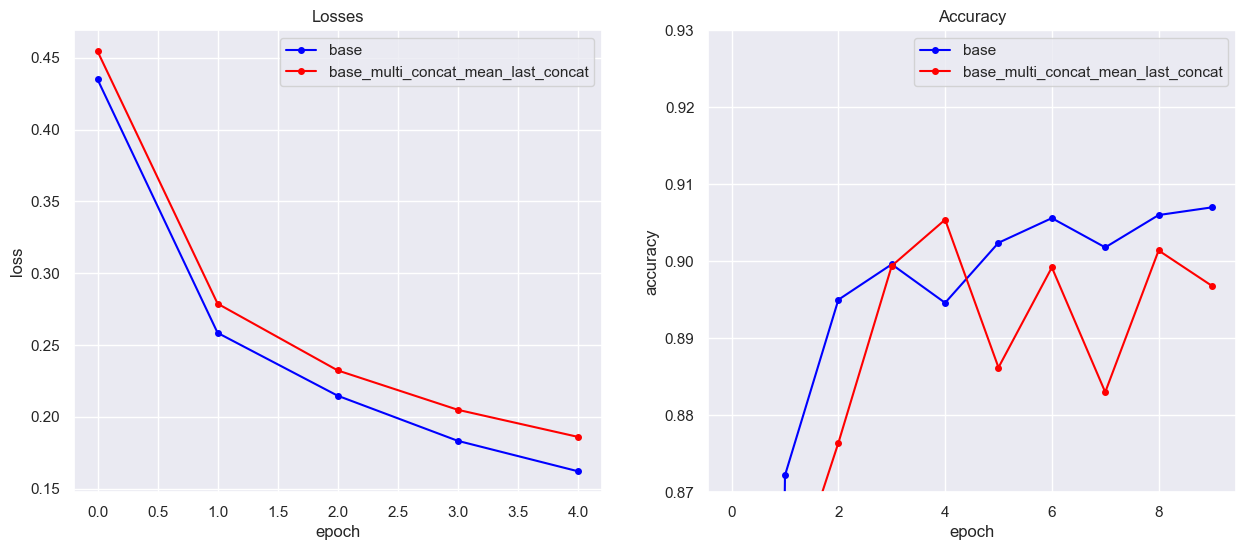

Accuracy = 0.9053999781608582
Хуже на 0.001600027084350586


In [22]:
aggregation_types = ['sum', 'max_norm', 'mean_norm', 'mean_last_concat', 'multi_concat']

agg_type = 'mean_last_concat'

model = CharLM(hidden_dim=256, vocab_size=len(vocab), aggregation_type=agg_type).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters())

model_loss, model_acc = train_model(model, criterion, optimizer, model_name=f'{name_model}_{agg_type}')

In [23]:
# aggregation_types = ['sum', 'max_norm', 'mean_norm', 'mean_last_concat', 'multi_concat']

# agg_type = 'sum'

# model = CharLM(hidden_dim=256, vocab_size=len(vocab), aggregation_type=agg_type).to(device)
# criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
# optimizer = torch.optim.Adam(model.parameters())

# model_loss, model_acc = train_model(model, criterion, optimizer, model_name=f'{name_model}_{agg_type}')

In [24]:
# aggregation_types = ['sum', 'max_norm', 'mean_norm', 'mean_last_concat', 'multi_concat']

# agg_type = 'max_norm'

# model = CharLM(hidden_dim=256, vocab_size=len(vocab), aggregation_type=agg_type).to(device)
# criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
# optimizer = torch.optim.Adam(model.parameters())

# model_loss, model_acc = train_model(model, criterion, optimizer, model_name=f'{name_model}_{agg_type}')

In [25]:
# aggregation_types = ['sum', 'max_norm', 'mean_norm', 'mean_last_concat', 'multi_concat']

# agg_type = 'mean_norm'

# model = CharLM(hidden_dim=256, vocab_size=len(vocab), aggregation_type=agg_type).to(device)
# criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
# optimizer = torch.optim.Adam(model.parameters())

# model_loss, model_acc = train_model(model, criterion, optimizer, model_name=f'{name_model}_{agg_type}')

In [26]:
# aggregation_types = ['sum', 'max_norm', 'mean_norm', 'mean_last_concat', 'multi_concat']

# agg_type = 'multi_concat'

# model = CharLM(hidden_dim=256, vocab_size=len(vocab), aggregation_type=agg_type).to(device)
# criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
# optimizer = torch.optim.Adam(model.parameters())

# model_loss, model_acc = train_model(model, criterion, optimizer, model_name=f'{name_model}_{agg_type}')

#### Увеличение количества рекуррентных слоев модели

Изменение num_layers и dropout_rate (в связке между новыми слоями)

In [27]:
import itertools

num_layers_list = [1, 2, 3]
dropout_rates = [0.0, 0.3]
agg_type = 'mean'
num_epoch = 5

for num_layers, dropout_rate in itertools.product(num_layers_list, dropout_rates):
    model = CharLM(hidden_dim=256, vocab_size=len(vocab), aggregation_type=agg_type, num_layers=num_layers, dropout_rate=dropout_rate).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    model_loss, model_acc = train_model(model, criterion, optimizer, model_name=f'{name_model}_{agg_type}_nl{num_layers}_drop{dropout_rate}',
                                        aggregation_type=agg_type, plot=False, num_epoch=num_epoch)    


base_multi_concat_mean_nl1_drop0.0 модель


Training base_multi_concat_mean_nl1_drop0.0:   0%|          | 0/5 [00:00<?, ?it/s]

Accuracy = 0.9089999794960022
Лучше на 0.001999974250793457

base_multi_concat_mean_nl1_drop0.3 модель


Training base_multi_concat_mean_nl1_drop0.3:   0%|          | 0/5 [00:00<?, ?it/s]

Accuracy = 0.9059999585151672
Хуже на 0.001000046730041504

base_multi_concat_mean_nl2_drop0.0 модель


...

Accuracy = 0.9103999733924866
Лучше на 0.003399968147277832

base_multi_concat_mean_nl3_drop0.0 модель


Training base_multi_concat_mean_nl3_drop0.0:   0%|          | 0/5 [00:00<?, ?it/s]

Accuracy = 0.9031999707221985
Хуже на 0.003800034523010254

base_multi_concat_mean_nl3_drop0.3 модель


Training base_multi_concat_mean_nl3_drop0.3:   0%|          | 0/5 [00:00<?, ?it/s]

Accuracy = 0.9017999768257141
Хуже на 0.005200028419494629


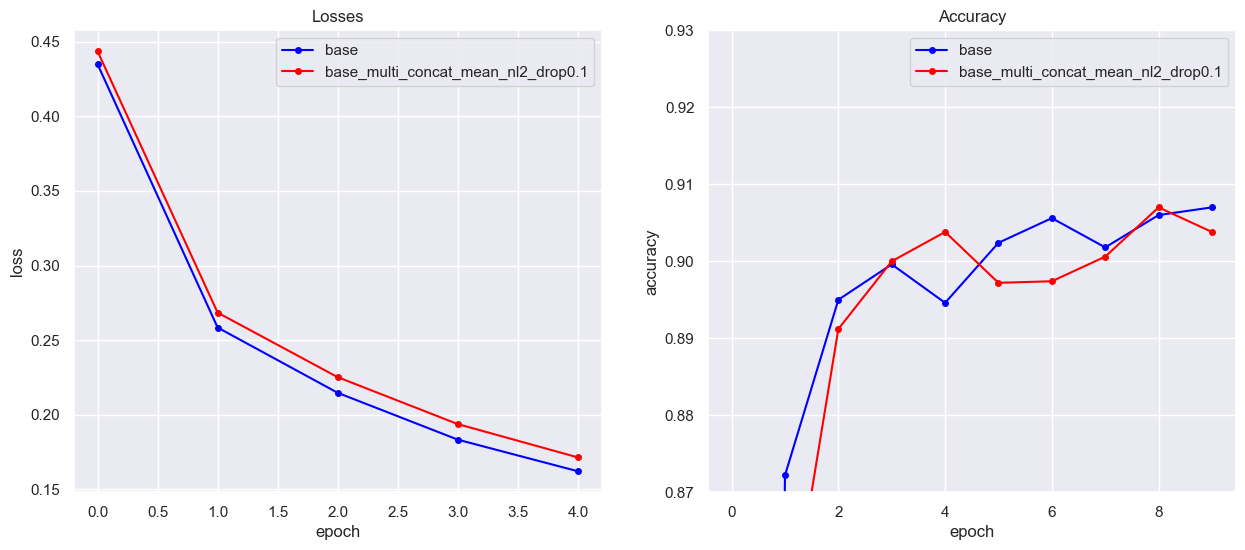

Accuracy = 0.9070000052452087
Хуже на 0.0


In [28]:
num_layers = 2
dropout_rate = 0.1
agg_type = 'mean'

model = CharLM(hidden_dim=256, vocab_size=len(vocab), aggregation_type=agg_type, num_layers=num_layers, dropout_rate=dropout_rate).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters())

model_loss, model_acc = train_model(model, criterion, optimizer, model_name=f'{name_model}_{agg_type}_nl{num_layers}_drop{dropout_rate}')

In [29]:
# num_layers = 2
# dropout_rate = 0
# agg_type = 'mean'

# model = CharLM(hidden_dim=256, vocab_size=len(vocab), aggregation_type=agg_type, num_layers=num_layers, dropout_rate=dropout_rate).to(device)
# criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
# optimizer = torch.optim.Adam(model.parameters())

# model_loss, model_acc = train_model(model, criterion, optimizer, model_name=f'{name_model}_{agg_type}_nl{num_layers}_drop{dropout_rate}')

In [30]:
# num_layers = 2
# dropout_rate = 0.2
# agg_type = 'mean'

# model = CharLM(hidden_dim=256, vocab_size=len(vocab), aggregation_type=agg_type, num_layers=num_layers, dropout_rate=dropout_rate).to(device)
# criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
# optimizer = torch.optim.Adam(model.parameters())

# model_loss, model_acc = train_model(model, criterion, optimizer, model_name=f'{name_model}_{agg_type}_nl{num_layers}_drop{dropout_rate}')

In [31]:
# num_layers = 3
# dropout_rate = 0
# agg_type = 'mean'

# model = CharLM(hidden_dim=256, vocab_size=len(vocab), aggregation_type=agg_type, num_layers=num_layers, dropout_rate=dropout_rate).to(device)
# criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
# optimizer = torch.optim.Adam(model.parameters())

# model_loss, model_acc = train_model(model, criterion, optimizer, model_name=f'{name_model}_{agg_type}_nl{num_layers}_drop{dropout_rate}')

In [32]:
# num_layers = 3
# dropout_rate = 0.3
# agg_type = 'mean'

# model = CharLM(hidden_dim=256, vocab_size=len(vocab), aggregation_type=agg_type, num_layers=num_layers, dropout_rate=dropout_rate).to(device)
# criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
# optimizer = torch.optim.Adam(model.parameters())

# model_loss, model_acc = train_model(model, criterion, optimizer, model_name=f'{name_model}_{agg_type}_nl{num_layers}_drop{dropout_rate}')

#### LSTM модель

In [33]:
class LSTMCharLM(nn.Module):
    def __init__(
        self, hidden_dim: int, 
        vocab_size: int, 
        num_classes: int = 4,
        aggregation_type: str = 'max',
        num_layers=1
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, batch_first=True, num_layers=num_layers)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

        self.aggregation_type = aggregation_type

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0] #[batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1) #[batch_size, hidden_dim]
        else:
            raise ValueError('Invalid aggregation_type')

        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, hidden_dim]
        prediction = self.projection(self.non_lin(output))  # [batch_size, num_classes]

        return prediction

In [34]:
name_model = 'lstm'

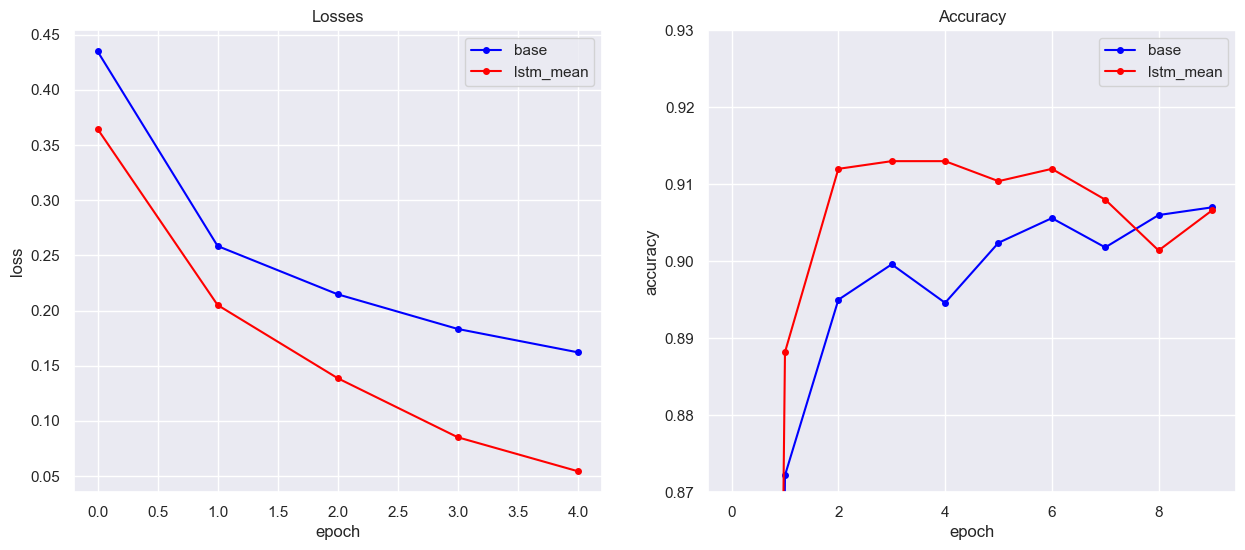

Accuracy = 0.9129999876022339
Лучше на 0.0059999823570251465


In [35]:
agg_type = 'mean'

model = LSTMCharLM(hidden_dim=256, vocab_size=len(vocab), aggregation_type=agg_type).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters())

model_loss, model_acc = train_model(model, criterion, optimizer, model_name=f'{name_model}_{agg_type}')

#### GRU модель

In [36]:
class GRUCharLM(nn.Module):
    def __init__(
        self, hidden_dim: int, 
        vocab_size: int, 
        num_classes: int = 4,
        aggregation_type: str = 'max',
        num_layers=1
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True, num_layers=num_layers)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

        self.aggregation_type = aggregation_type

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0] #[batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1) #[batch_size, hidden_dim]
        else:
            raise ValueError('Invalid aggregation_type')

        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, hidden_dim]
        prediction = self.projection(self.non_lin(output))  # [batch_size, num_classes]

        return prediction

In [37]:
name_model = 'gru'

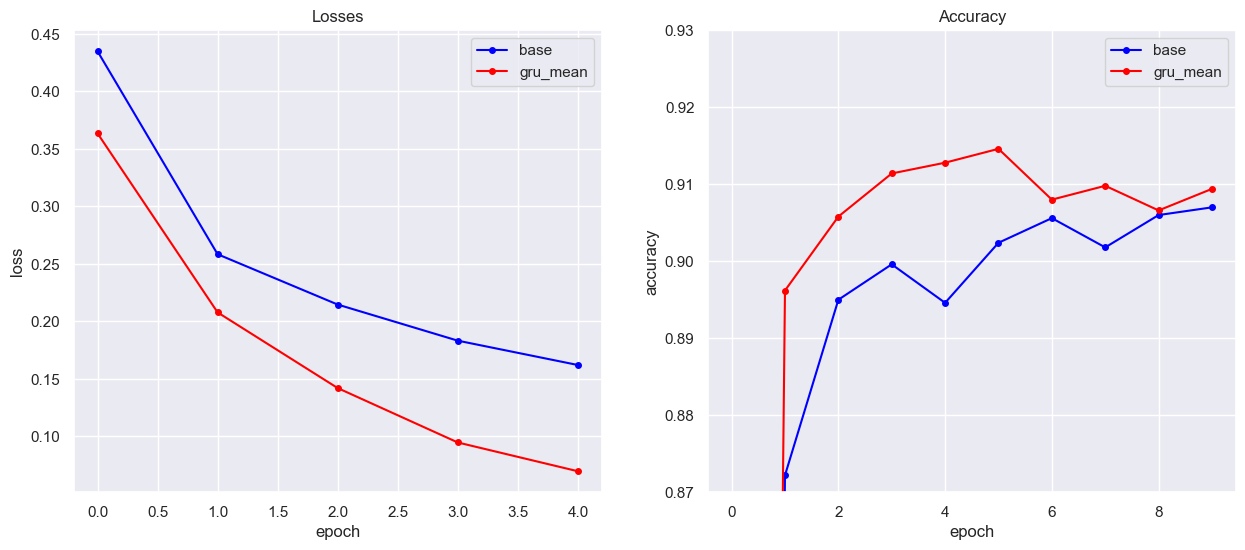

Accuracy = 0.9145999550819397
Лучше на 0.007599949836730957


In [38]:
agg_type = 'mean'

model = GRUCharLM(hidden_dim=256, vocab_size=len(vocab), aggregation_type=agg_type).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters())

model_loss, model_acc = train_model(model, criterion, optimizer, model_name=f'{name_model}_{agg_type}')

#### Bidirectional RNN модель

In [39]:
class BidirectCharLM(nn.Module):
    def __init__(
        self, hidden_dim: int, 
        vocab_size: int, 
        num_classes: int = 4,
        aggregation_type: str = 'max',
        num_layers=1
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.RNN(hidden_dim, hidden_dim, batch_first=True, bidirectional=True, num_layers=num_layers)
        self.linear = nn.Linear(hidden_dim * 2, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

        self.aggregation_type = aggregation_type

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0] #[batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1) #[batch_size, hidden_dim]
        else:
            raise ValueError('Invalid aggregation_type')

        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, hidden_dim]
        prediction = self.projection(self.non_lin(output))  # [batch_size, num_classes]

        return prediction

In [40]:
name_model = 'bidirect'

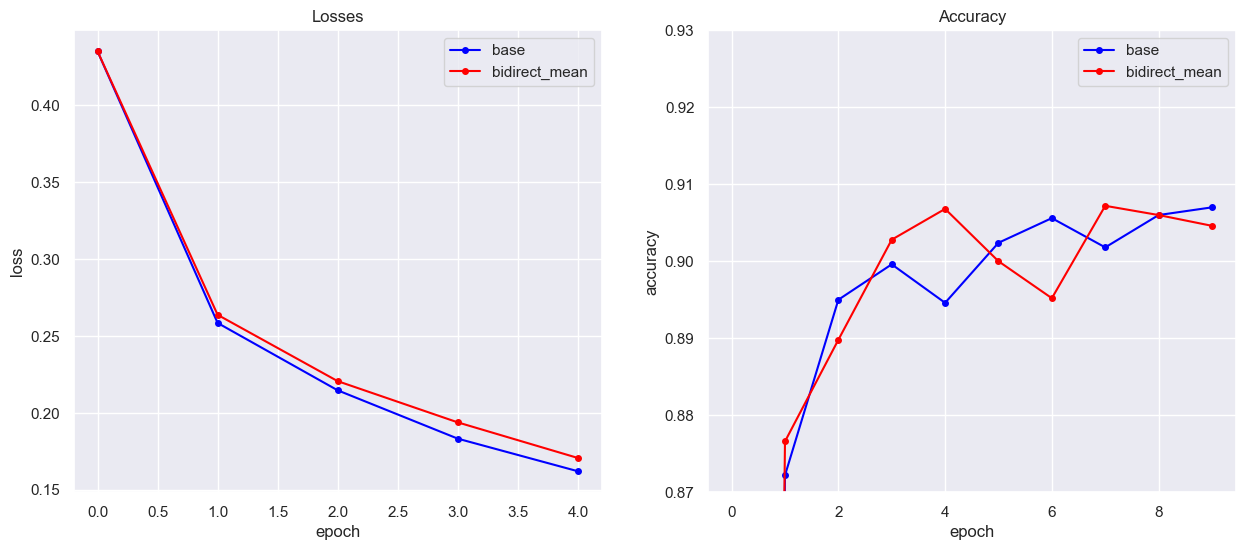

Accuracy = 0.9071999788284302
Лучше на 0.00019997358322143555


In [41]:
agg_type = 'mean'

model = BidirectCharLM(hidden_dim=256, vocab_size=len(vocab), aggregation_type=agg_type).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters())

model_loss, model_acc = train_model(model, criterion, optimizer, model_name=f'{name_model}_{agg_type}')

#### Подбор гиперпараметров и обучение до сходимости

Для чистоты эксперимента обучим базовую модель на 10 эпохах

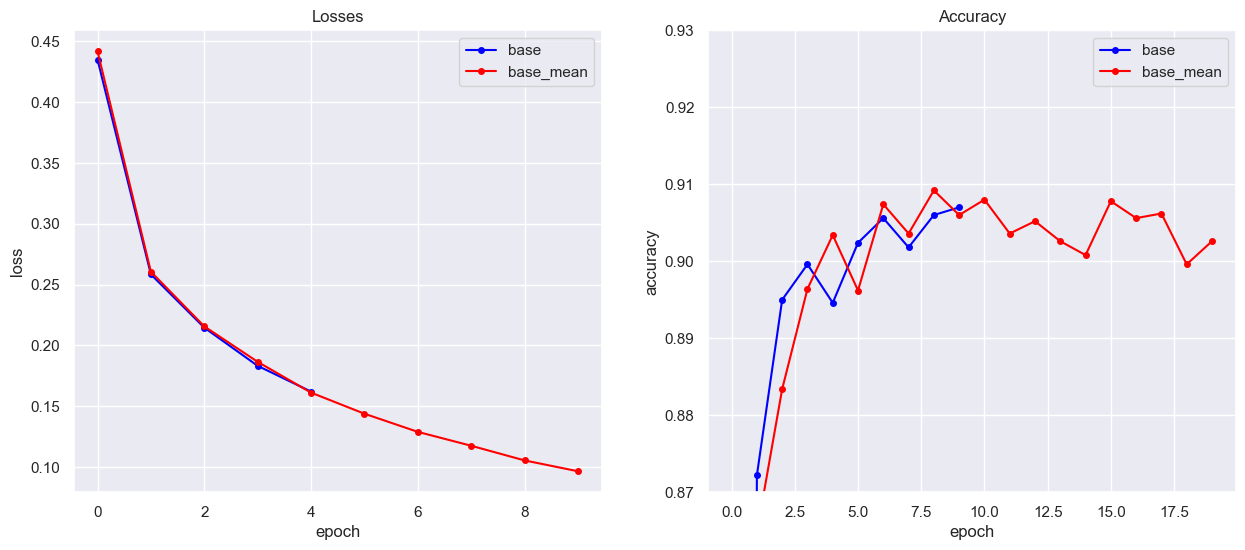

Accuracy = 0.9091999530792236
Лучше на 0.0021999478340148926


In [42]:
num_epoch = 10

name_model = 'base'

agg_type = 'mean'

model = CharLM(hidden_dim=256, vocab_size=len(vocab), aggregation_type=agg_type).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters())

base_mean_loss, base_mean_acc = train_model(model, criterion, optimizer, model_name=f'{name_model}_{agg_type}',
                                            aggregation_type=agg_type, plot=True, num_epoch=num_epoch, base_mean_loss=base_mean_loss, base_mean_acc=base_mean_acc)

In [43]:
display(df_stats)

,Model,Min_loss,Max_accuracy,Diff_accuracy
0,base_mean,0.096650,0.9092,0.0022
1,base_max,0.207958,0.9042,-0.0028
2,base_sum,0.530286,0.8528,-0.0542
3,base_max_norm,0.170809,0.9080,0.0010
4,base_mean_norm,0.169707,0.9054,-0.0016
5,base_mean_last_concat,0.186609,0.8986,-0.0084
6,base_multi_concat,0.281257,0.8942,-0.0128
7,base_multi_concat_mean_last_concat,0.186061,0.9054,-0.0016
8,base_multi_concat_mean_nl1_drop0.0,0.163023,0.9090,0.0020
9,base_multi_concat_mean_nl1_drop0.3,0.161050,0.9060,-0.0010


Выберем модель с наилучшим качеством при стандартных параметрах: <br>
LSTM модель

In [ ]:
class LSTMCharLM(nn.Module):
    def __init__(
        self, hidden_dim: int, 
        vocab_size: int, 
        num_classes: int = 4,   # 4 класса
        aggregation_type: str = 'max',
        num_layers=1,
        dropout_rate=0
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)

        if num_layers > 1:
            dropout = dropout_rate
        else:
            dropout = 0

        self.rnn = nn.LSTM(hidden_dim, hidden_dim, batch_first=True, num_layers=num_layers, dropout=dropout)
        
        if aggregation_type == 'mean_last_concat':
            agg_dim = hidden_dim * 2
        else:
            agg_dim = hidden_dim
        
        self.linear = nn.Linear(agg_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=dropout if dropout else 0.1)

        self.aggregation_type = aggregation_type

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]
        # Max
        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0] #[batch_size, hidden_dim]
        # Mean
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1) #[batch_size, hidden_dim]
        # Mean_last_concat
        elif self.aggregation_type == 'mean_last_concat':
            mean_pool = output.mean(dim=1)
            last = output[:, -1, :]
            output = torch.cat([mean_pool, last], dim=1)  # [batch_size, 2*hidden_dim]
        else:
            raise ValueError('Invalid aggregation_type')

        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, hidden_dim]
        prediction = self.projection(self.non_lin(output))  # [batch_size, num_classes]

        return prediction

Для этой модели реализуем перебор параметров и выберем наилучший наибор параметров

In [45]:
import itertools

name_model = 'lstm'

hidden_dims = [256, 384, 512]
aggregation_types = ['mean', 'max', 'mean_last_concat']
num_layers_list = [1, 2, 3]
dropout_rates = [0.0, 0.1, 0.2, 0.3]

num_epoch = 7 # увеличим количество эпох до 7 для лучшей сходимости

best_acc = 0
best_params = {}

for hidden_dim, num_layers, dropout_rate, agg_type in itertools.product(hidden_dims, num_layers_list, dropout_rates, aggregation_types):
    model = LSTMCharLM(hidden_dim=hidden_dim, vocab_size=len(vocab), aggregation_type=agg_type, num_layers=num_layers, dropout_rate=dropout_rate).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    model_loss, model_acc = train_model(model, criterion, optimizer, model_name=f'{name_model}_{agg_type}_hd{hidden_dim}_nl{num_layers}_drop{dropout_rate}',
                                        aggregation_type=agg_type, plot=False, num_epoch=num_epoch, base_mean_loss=base_mean_loss, base_mean_acc=base_mean_acc)

    curr_acc = max(model_acc)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_params = {
            'hidden_dim': hidden_dim,
            'aggregation_type': agg_type,
            'num_layers': num_layers,
            'dropout_rate': dropout_rate
        }


lstm_mean_hd256_nl1_drop0.0 модель


Training lstm_mean_hd256_nl1_drop0.0:   0%|          | 0/7 [00:00<?, ?it/s]

Accuracy = 0.917199969291687
Лучше на 0.008000016212463379

lstm_max_hd256_nl1_drop0.0 модель


Training lstm_max_hd256_nl1_drop0.0:   0%|          | 0/7 [00:00<?, ?it/s]

Accuracy = 0.9085999727249146
Лучше на 0.004999995231628418

lstm_mean_last_concat_hd256_nl1_drop0.0 модель


...

Accuracy = 0.9167999625205994
Лучше на 0.007600009441375732

lstm_max_hd512_nl3_drop0.3 модель


Training lstm_max_hd512_nl3_drop0.3:   0%|          | 0/7 [00:00<?, ?it/s]

Accuracy = 0.9179999828338623
Лучше на 0.014400005340576172

lstm_mean_last_concat_hd512_nl3_drop0.3 модель


Training lstm_mean_last_concat_hd512_nl3_drop0.3:   0%|          | 0/7 [00:00<?, ?it/s]

Accuracy = 0.9177999496459961
Лучше на 0.008599996566772461


In [46]:
print(f'Лучшая accuracy: {best_acc}')
print(f'Лучшие параметры: {best_params}') 

Лучшая accuracy: 0.9221999645233154
Лучшие параметры: {'hidden_dim': 512, 'aggregation_type': 'mean', 'num_layers': 1, 'dropout_rate': 0.3}


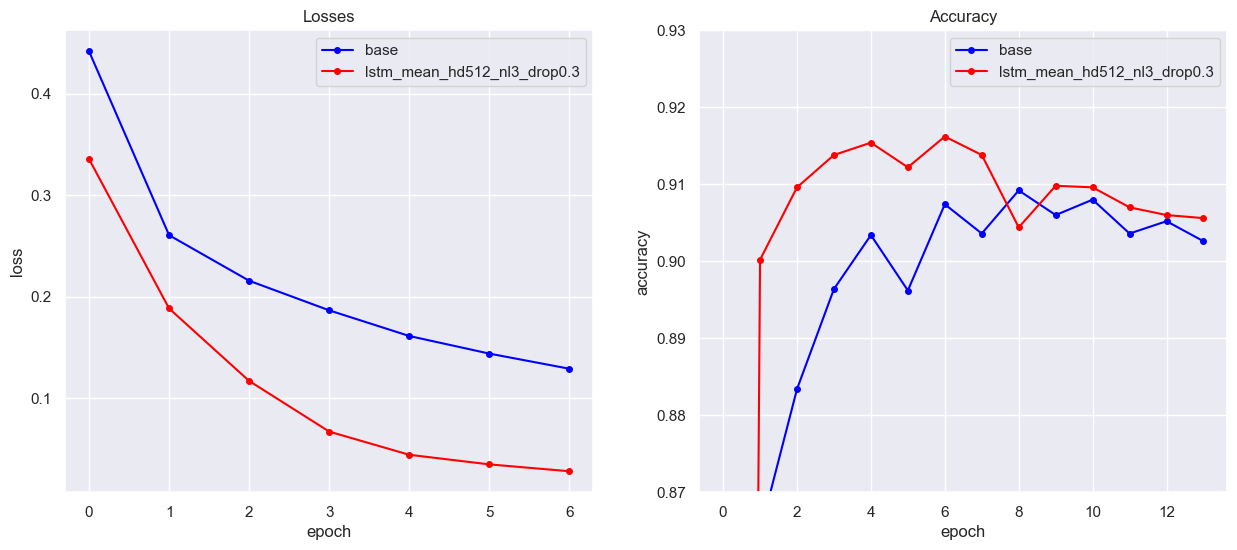

Accuracy = 0.9161999821662903
Лучше на 0.00700002908706665


In [47]:
num_epoch = 7

model = LSTMCharLM(**best_params, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters())

agg_type = best_params['aggregation_type']

model_loss, model_acc = train_model(model, criterion, optimizer, model_name=f'{name_model}_{agg_type}_hd{hidden_dim}_nl{num_layers}_drop{dropout_rate}',
                                    aggregation_type=agg_type, plot=True, num_epoch=num_epoch, base_mean_loss=base_mean_loss, base_mean_acc=base_mean_acc)

#### Выбор оптимизатора

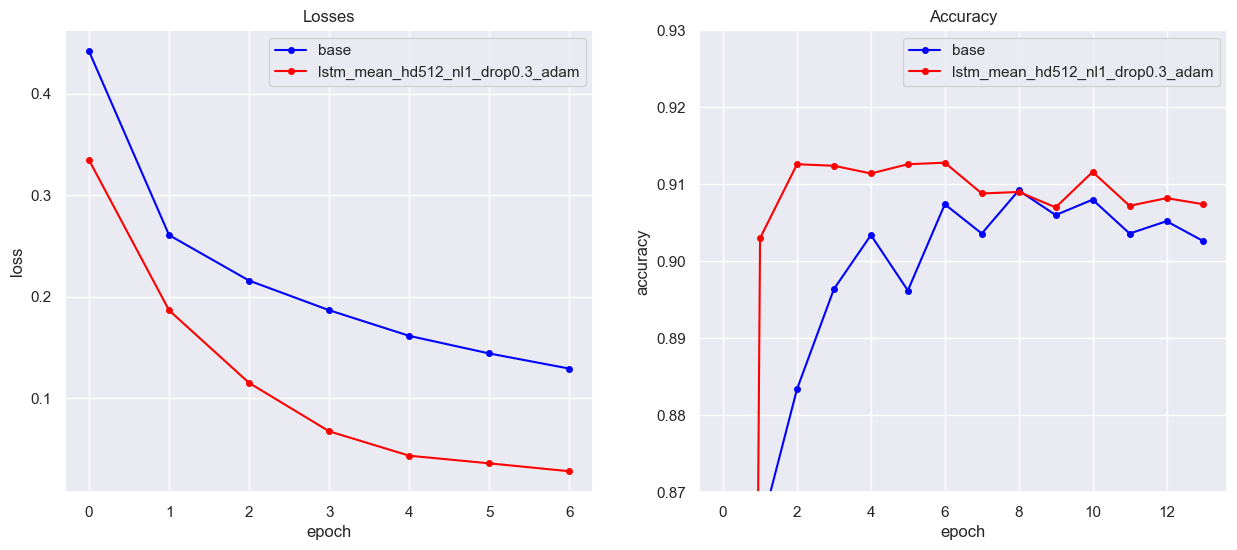

Accuracy = 0.9127999544143677
Лучше на 0.003600001335144043


In [66]:
['adam', 'adamW_wd01', 'adamW_wd03', 'adamW_wd05']

num_epoch = 7

best_params = {'hidden_dim': 512, 'aggregation_type': 'mean', 'num_layers': 1, 'dropout_rate': 0.3}
agg_type = best_params['aggregation_type']
name = 'adam'

model = LSTMCharLM(**best_params, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters())

model_loss, model_acc = train_model(model, criterion, optimizer, 
                                    model_name=f'{name_model}_{agg_type}_hd{best_params["hidden_dim"]}_nl{best_params["num_layers"]}_drop{best_params["dropout_rate"]}_{name}',
                                    aggregation_type=agg_type, plot=True, num_epoch=num_epoch, base_mean_loss=base_mean_loss, base_mean_acc=base_mean_acc)

curr_acc = max(model_acc)
if curr_acc > best_acc:
    best_acc = curr_acc
    best_optimizer_name = name
    best_optimizer = optimizer

Adam заменим на AdamW и попробуем подобрать для него наилучшие параметры

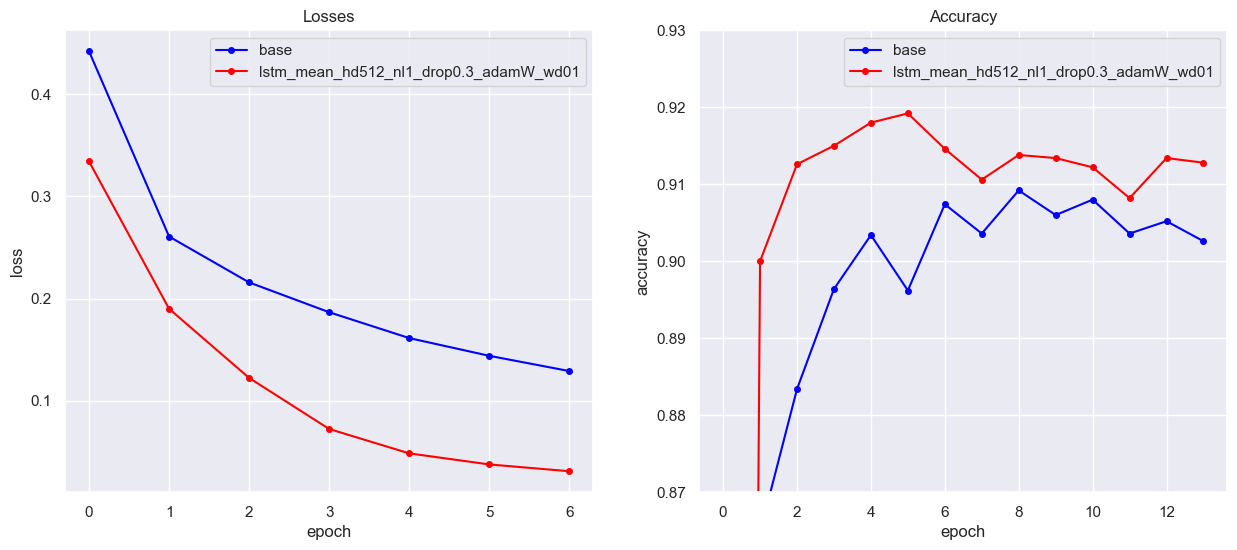

Accuracy = 0.9192000031471252
Лучше на 0.010000050067901611


In [67]:
['adam', 'adamW_wd01', 'adamW_wd03', 'adamW_wd05']

num_epoch = 7

best_params = {'hidden_dim': 512, 'aggregation_type': 'mean', 'num_layers': 1, 'dropout_rate': 0.3}
agg_type = best_params['aggregation_type']
name = 'adamW_wd01'

model = LSTMCharLM(**best_params, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

model_loss, model_acc = train_model(model, criterion, optimizer, 
                                    model_name=f'{name_model}_{agg_type}_hd{best_params["hidden_dim"]}_nl{best_params["num_layers"]}_drop{best_params["dropout_rate"]}_{name}',
                                    aggregation_type=agg_type, plot=True, num_epoch=num_epoch, base_mean_loss=base_mean_loss, base_mean_acc=base_mean_acc)

curr_acc = max(model_acc)
if curr_acc > best_acc:
    best_acc = curr_acc
    best_optimizer_name = name
    best_optimizer = optimizer

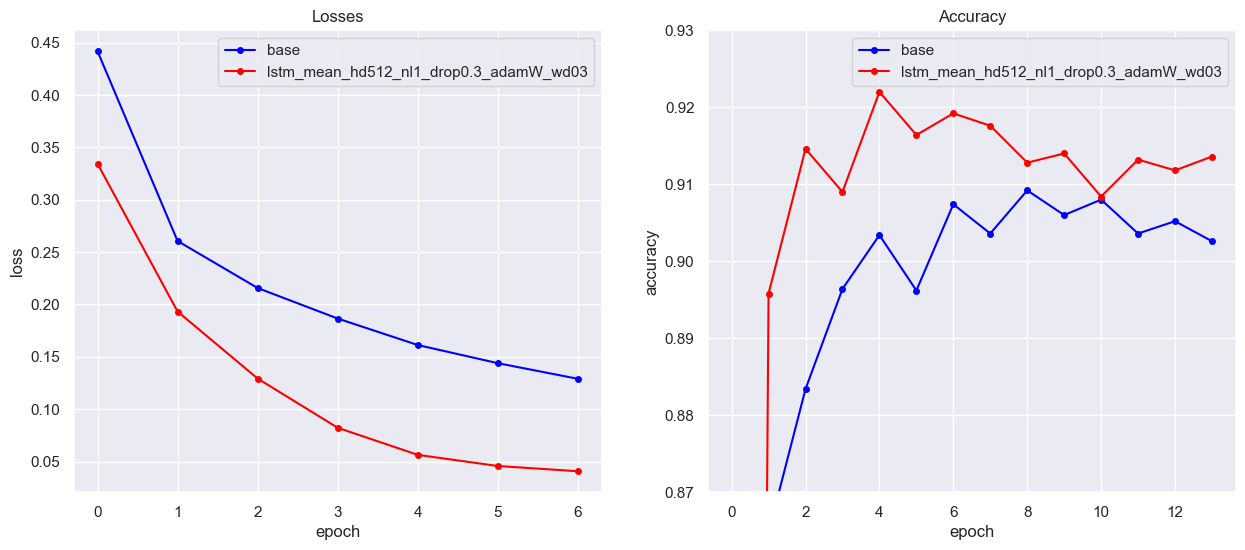

Accuracy = 0.921999990940094
Лучше на 0.012800037860870361


In [68]:
['adam', 'adamW_wd01', 'adamW_wd03', 'adamW_wd05']

num_epoch = 7

best_params = {'hidden_dim': 512, 'aggregation_type': 'mean', 'num_layers': 1, 'dropout_rate': 0.3}
agg_type = best_params['aggregation_type']
name = 'adamW_wd03'

model = LSTMCharLM(**best_params, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.03)

model_loss, model_acc = train_model(model, criterion, optimizer, 
                                    model_name=f'{name_model}_{agg_type}_hd{best_params["hidden_dim"]}_nl{best_params["num_layers"]}_drop{best_params["dropout_rate"]}_{name}',
                                    aggregation_type=agg_type, plot=True, num_epoch=num_epoch, base_mean_loss=base_mean_loss, base_mean_acc=base_mean_acc)

curr_acc = max(model_acc)
if curr_acc > best_acc:
    best_acc = curr_acc
    best_optimizer_name = name
    best_optimizer = optimizer

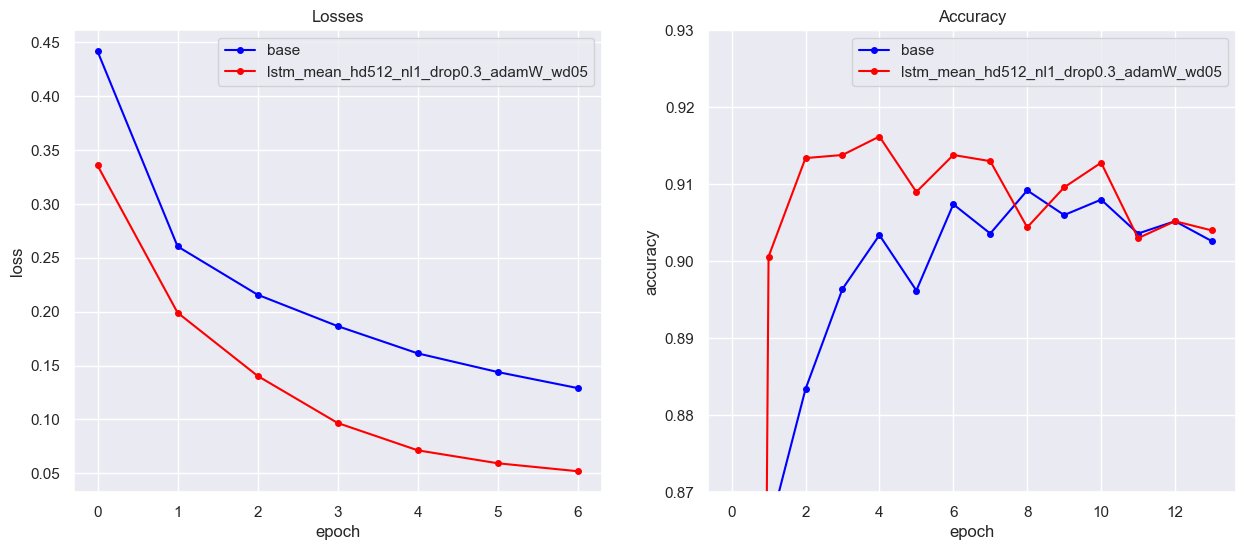

Accuracy = 0.9161999821662903
Лучше на 0.00700002908706665


In [69]:
['adam', 'adamW_wd01', 'adamW_wd03', 'adamW_wd05']

num_epoch = 7

best_params = {'hidden_dim': 512, 'aggregation_type': 'mean', 'num_layers': 1, 'dropout_rate': 0.3}
agg_type = best_params['aggregation_type']
name = 'adamW_wd05'

model = LSTMCharLM(**best_params, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.05)

model_loss, model_acc = train_model(model, criterion, optimizer, 
                                    model_name=f'{name_model}_{agg_type}_hd{best_params["hidden_dim"]}_nl{best_params["num_layers"]}_drop{best_params["dropout_rate"]}_{name}',
                                    aggregation_type=agg_type, plot=True, num_epoch=num_epoch, base_mean_loss=base_mean_loss, base_mean_acc=base_mean_acc)

curr_acc = max(model_acc)
if curr_acc > best_acc:
    best_acc = curr_acc
    best_optimizer_name = name
    best_optimizer = optimizer

In [74]:
print(f'Лучшая accuracy: {best_acc}')
print(f'Лучший оптимайзер: {best_optimizer_name}')

Лучшая accuracy: 0.921999990940094
Лучший оптимайзер: adamW_wd03


### Получение высокого качества (3 балла)


В конце вашей работы вы должны указать, какая из моделей дала лучший результат, и вывести качество, которое дает лучшая модель, с помощью функции `evaluate`. Ваша модель будет оцениваться по метрике `accuracy` следующим образом:
* $accuracy < 0.9$ --- 0 баллов;
* $0.9 \leqslant accuracy < 0.91$ --- 1 балл;
* $0.91 \leqslant accuracy < 0.915$ --- 2 балла;
* $0.915 \leqslant accuracy$ --- 3 балла.

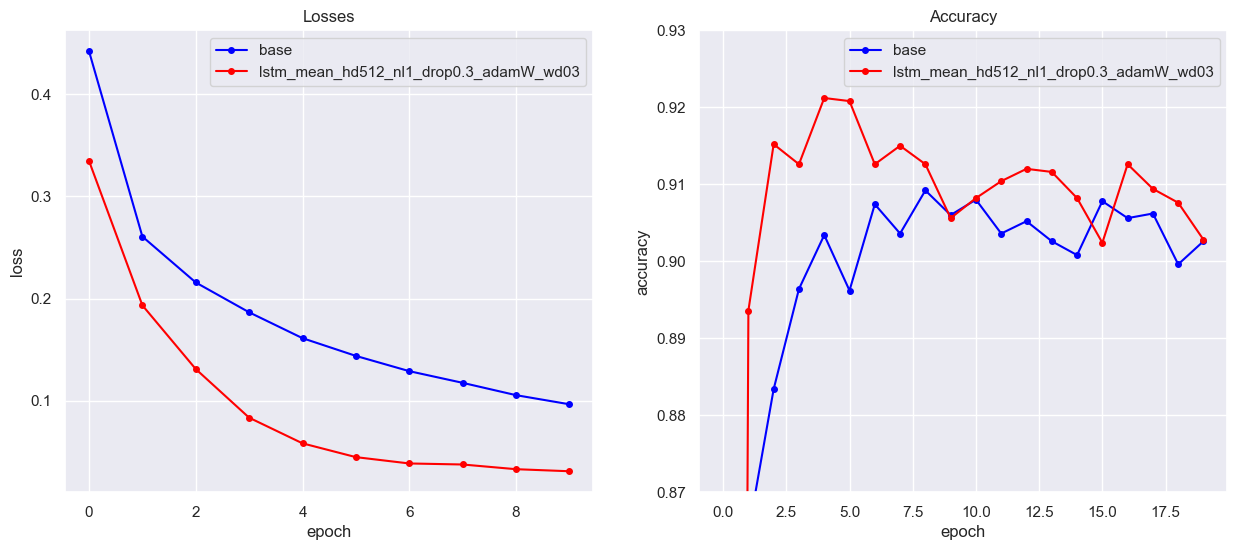

Accuracy = 0.9211999773979187
Лучше на 0.012000024318695068


In [96]:
name_model = 'lstm'
best_params = {'hidden_dim': 512, 'aggregation_type': 'mean', 'num_layers': 1, 'dropout_rate': 0.3}
agg_type = best_params['aggregation_type']
name = 'adamW_wd03'

num_epoch = 10

model = LSTMCharLM(**best_params, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.03)

model_loss, model_acc = train_model(model, criterion, optimizer, 
                                    model_name=f'{name_model}_{agg_type}_hd{best_params["hidden_dim"]}_nl{best_params["num_layers"]}_drop{best_params["dropout_rate"]}_{name}',
                                    aggregation_type=agg_type, plot=True, num_epoch=num_epoch, base_mean_loss=base_mean_loss, base_mean_acc=base_mean_acc)

In [97]:
print(f'Лучшая accuracy: {max(model_acc)}')
print(f'{name_model}_{agg_type}_hd{best_params["hidden_dim"]}_nl{best_params["num_layers"]}_drop{best_params["dropout_rate"]}_{name}')

Лучшая accuracy: 0.9211999773979187
lstm_mean_hd512_nl1_drop0.3_adamW_wd03


### Оформление отчета (2 балла)

В конце работы подробно опишите все проведенные эксперименты. 
* Укажите, какие из экспериментов принесли улучшение, а какие --- нет. 
* Проанализируйте графики сходимости моделей в проведенных экспериментах. Являются ли колебания качества обученных моделей существенными в зависимости от эпохи обучения, или же сходимость стабильная? 
* Укажите, какая модель получилась оптимальной.

* Было опробовано: <br>
-- Агрегации ['max', 'mean', 'sum', 'max_norm', 'mean_norm', 'mean_last_concat', 'multi_concat']. <br>
Хорошо себя показали агрегации: 'max', 'mean', 'mean_last_concat', 'multi_concat. <br>
-- Изменение num_layers и dropout_rate. <br>
Прирост точности был при num_layers=2, но был незначительный. <br>
-- Модели LSTM, GRU и Bidirectional RNN. <br>
Все они показали точность выше, чем Base model. Выбрал LSTM. <br>
-- Подбор гиперпараметров для модели LSTM, количество эпох было увеличено для лучшей сходимости. <br>
Подбор осуществлялся по гиперпараметрам с дальнейшем выбором сохранением лучшего набор: <br>
hidden_dims = [256, 384, 512] <br>
aggregation_types = ['mean', 'max', 'mean_last_concat'] <br>
num_layers_list = [1, 2, 3] <br>
dropout_rates = [0.0, 0.1, 0.2, 0.3]. <br>
-- Выбор оптимизатора Adam, AdamW с различными параметрами регуляризации. <br>
<br>
* Лосс при проведении экспериментов стабильно уменьшался, выходил на плато примерно к 5 эпохе. <br>
Accuracy во всех моделях на валидационном датасете выходит на плато с к 3-5 эпохе с незначительными флуктуациями (чуть позже при увеличении слоев). <br>
<br>
* Модель LSTM с подобранными гиперпараметрами, агрегацией и оптимизатором <br>
('hidden_dim': 512, 'aggregation_type': 'mean', 'num_layers': 1, 'dropout_rate': 0.3, AdamW(lr=0.001, weight_decay=0.03))<br> 
показала лучший результат, который составил Accuracy ~ 0.92.

In [106]:
df_stats_sorted_acc = df_stats.sort_values('Max_accuracy', ascending=False, ignore_index=True).copy()
display(df_stats_sorted_acc.head(10))

,Model,Min_loss,Max_accuracy,Diff_accuracy
0,lstm_mean_hd512_nl1_drop0.3,0.029084,0.9222,0.0130
1,lstm_mean_last_concat_hd384_nl2_drop0.0,0.029686,0.9210,0.0118
2,lstm_mean_hd384_nl1_drop0.3,0.026763,0.9210,0.0118
3,lstm_mean_hd512_nl1_drop0.0,0.028680,0.9208,0.0116
4,lstm_mean_hd384_nl3_drop0.2,0.043459,0.9206,0.0114
5,lstm_mean_hd256_nl3_drop0.2,0.046855,0.9204,0.0112
6,lstm_max_hd512_nl3_drop0.0,0.043328,0.9202,0.0166
7,lstm_mean_hd384_nl3_drop0.1,0.039178,0.9196,0.0104
8,lstm_mean_last_concat_hd512_nl2_drop0.3,0.039498,0.9196,0.0104
9,lstm_max_hd512_nl2_drop0.3,0.055904,0.9194,0.0158


In [ ]:
# df_stats_sorted_acc.to_csv('hw_2_model_stats.csv', index=False)